In [ ]:
import sys, os, pathlib
sys.path.append("/root/shared/gitrepos/smart-mechanotransduction/utils")
sys.path.append("/root/shared/gitrepos/smart-comp-sci/mechanotransduction-example")
cur_dir = str(pathlib.Path.cwd() / "..")
import smart_analysis
from matplotlib import pyplot as plt
import matplotlib
plt.style.use(f"{cur_dir}/plotting/smart_plots.mplstyle")
matplotlib.rcParams.update({'figure.figsize': (5,4)})
import numpy as np
import dolfin as d
import h5py

In [ ]:
import warnings
from matplotlib.collections import LineCollection

def colored_line(x, y, c, ax, **lc_kwargs):
    """
    Plot a line with a color specified along the line by a third value.

    It does this by creating a collection of line segments. Each line segment is
    made up of two straight lines each connecting the current (x, y) point to the
    midpoints of the lines connecting the current point with its two neighbors.
    This creates a smooth line with no gaps between the line segments.

    Parameters
    ----------
    x, y : array-like
        The horizontal and vertical coordinates of the data points.
    c : array-like
        The color values, which should be the same size as x and y.
    ax : Axes
        Axis object on which to plot the colored line.
    **lc_kwargs
        Any additional arguments to pass to matplotlib.collections.LineCollection
        constructor. This should not include the array keyword argument because
        that is set to the color argument. If provided, it will be overridden.

    Returns
    -------
    matplotlib.collections.LineCollection
        The generated line collection representing the colored line.
    """
    if "array" in lc_kwargs:
        warnings.warn('The provided "array" keyword argument will be overridden')

    # Default the capstyle to butt so that the line segments smoothly line up
    default_kwargs = {"capstyle": "butt"}
    default_kwargs.update(lc_kwargs)

    # Compute the midpoints of the line segments. Include the first and last points
    # twice so we don't need any special syntax later to handle them.
    x = np.asarray(x)
    y = np.asarray(y)
    x_midpts = np.hstack((x[0], 0.5 * (x[1:] + x[:-1]), x[-1]))
    y_midpts = np.hstack((y[0], 0.5 * (y[1:] + y[:-1]), y[-1]))

    # Determine the start, middle, and end coordinate pair of each line segment.
    # Use the reshape to add an extra dimension so each pair of points is in its
    # own list. Then concatenate them to create:
    # [
    #   [(x1_start, y1_start), (x1_mid, y1_mid), (x1_end, y1_end)],
    #   [(x2_start, y2_start), (x2_mid, y2_mid), (x2_end, y2_end)],
    #   ...
    # ]
    coord_start = np.column_stack((x_midpts[:-1], y_midpts[:-1]))[:, np.newaxis, :]
    coord_mid = np.column_stack((x, y))[:, np.newaxis, :]
    coord_end = np.column_stack((x_midpts[1:], y_midpts[1:]))[:, np.newaxis, :]
    segments = np.concatenate((coord_start, coord_mid, coord_end), axis=1)

    lc = LineCollection(segments, **default_kwargs)
    lc.set_array(c)  # set the colors of each segment

    return ax.add_collection(lc)

In [ ]:
# plot lamin distribution instead
from smart import mesh_tools
rNP = 0.2#radList[mesh_num]
pNP  = 6.0#pitchList[mesh_num]
hNP = 2.5#3.0#heightList[mesh_num]
forceVal = 400.0
laminVal = 1.5
results_folder = f"/root/scratch/revision_coupled_nuc_sims/results_nanopillars_sweepForce_2026-09-13_revision_a0_0.5/nanopillars_r{rNP}_p{pNP}_h3_force{forceVal}"
# results_folder = "/root/shared/gitrepos/nuc_indent_testInner_largeNP"
loaded_mesh = mesh_tools.load_mesh(f"{results_folder}/mesh/nuc_mesh.h5")
mf2 = loaded_mesh.mf_facet
mf3 = loaded_mesh.mf_cell
test_mesh = d.create_meshview(mf2, 10)

test_file_ulin = f"{results_folder}/NE_alt_udef.h5"
test_file_lamin = f"{results_folder}/LaminA.h5"
test_file_yap = f"{results_folder}/YAPTAZ_nuc.h5"
yap_NC = np.loadtxt(f"{results_folder}/YAPTAZ_NC.txt")

Vtest = d.VectorFunctionSpace(test_mesh, "P", 1)
Vscalar = d.FunctionSpace(test_mesh, "P", 1)
ulin = d.Function(Vtest)
lamin_lin = d.Function(Vscalar)
xSubstrate = np.array([])
ySubstrate = np.array([])
xSteric = 0.2
zShift = hNP + xSteric
if hNP == 0:
    xMax = 8.5
    xSubstrate = np.array([-xMax,xMax])
    ySubstrate = np.array([hNP,hNP])
else:
    xMax = np.ceil(8.5/pNP) * pNP
    xNP = np.arange(-xMax, xMax+pNP, pNP)
    for i in range(len(xNP)):
        xCur = xNP[i] + np.array([-rNP, -rNP, rNP, rNP])
        yCur = np.array([0.0, hNP, hNP, 0.0])
        xSubstrate = np.append(xSubstrate, xCur)
        ySubstrate = np.append(ySubstrate, yCur)

tvec = np.loadtxt(f"{results_folder}/tvec.txt")
times = [300.0, 1000.0, 3000.0]# 300.0, 600.0, 900.0]
indices = []#[np.nonzero(kRamp==0.0)[0][-1]]
for i in range(len(times)):
    indices.append(np.argmin(np.abs(tvec-times[i])))
fig, ax = plt.subplots(1,len(indices),figsize=(8,4))
profiles = []
theta_profile = np.linspace(-np.pi, 0.0, 500)

for idx in range(len(indices)):#, 5, 10, 20, 50, 100, 175, 250]:
    i = indices[idx]
    cur_file = h5py.File(test_file_ulin, 'r')
    cur_array = cur_file['VisualisationVector'][f'{i}'][()]
    cur_array = cur_array.reshape((3*len(test_mesh.coordinates()),1))
    cur_file.close()

    lamin_file = h5py.File(test_file_lamin, 'r')#d.HDF5File(d.MPI.comm_world, test_file_ulin, "r")
    lamin_array = lamin_file['VisualisationVector'][f'{i}'][()]
    lamin_array = lamin_array.reshape((len(test_mesh.coordinates()),1))
    lamin_file.close()

    yap_file = h5py.File(test_file_yap, 'r')#d.HDF5File(d.MPI.comm_world, test_file_ulin, "r")
    yap_array = yap_file['VisualisationVector'][f'{i}'][()]
    yap_nuc_cur = np.average(yap_array)
    yap_file.close()
    yap_cyto_cur = yap_nuc_cur / yap_NC[i]

    dof_map = d.dof_to_vertex_map(Vtest)[:]
    dof_map_scalar = d.dof_to_vertex_map(Vscalar)[:]
    # array matches mesh ordering; reorder according to dof mapping for Vcur
    ulin.vector().set_local(cur_array[dof_map])
    ulin.vector().apply("insert")
    lamin_lin.vector().set_local(lamin_array[dof_map_scalar])
    lamin_lin.vector().apply("insert")

    zMax = np.max(test_mesh.coordinates()[:,2])
    zMin = np.min(test_mesh.coordinates()[:,2])
    rMax = np.max(np.sqrt(test_mesh.coordinates()[:,0]**2 + 
                        test_mesh.coordinates()[:,1]**2))
    aNuc = rMax
    zNuc = (zMax+zMin)/2
    bNuc = (zMax-zMin)/2
    assert np.abs(aNuc-bNuc) < 1e-4

    ulin.set_allow_extrapolation(True)
    lamin_lin.set_allow_extrapolation(True)
    # uy.set_allow_extrapolation(True)
    # uz.set_allow_extrapolation(True)
    theta_sample = np.linspace(0.0, 2*np.pi, 500)
    rvals = np.zeros_like(theta_sample)
    zvals = np.zeros_like(theta_sample)
    laminvals = np.zeros_like(theta_sample)
    for i in range(len(theta_sample)):
        rCur = bNuc*np.cos(theta_sample[i])
        rCurCalc = np.abs(rCur)
        zCur = zNuc + bNuc*np.sin(theta_sample[i])
        uCur = ulin(rCurCalc, 0.0, zCur)
        rvals[i] = rCur + np.sign(rCur)*uCur[0]
        zvals[i] = zCur + uCur[2]
        laminvals[i] = lamin_lin(rCurCalc, 0.0, zCur)
    rprofile = np.zeros_like(theta_profile)
    zprofile = np.zeros_like(theta_profile)
    laminprofile = np.zeros_like(theta_profile)
    for i in range(len(theta_profile)):
        rCur = bNuc*np.cos(theta_profile[i])
        rCurCalc = np.abs(rCur)
        zCur = zNuc + bNuc*np.sin(theta_profile[i])
        uCur = ulin(rCurCalc, 0.0, zCur)
        rprofile[i] = rCur + np.sign(rCur)*uCur[0]
        zprofile[i] = zCur + uCur[2]
        laminprofile[i] = lamin_lin(rCurCalc, 0.0, zCur)
    profiles.append([rprofile,zprofile,laminprofile])
    
    if hNP == 0:
        rvalsPM = np.array([0.0, 2*rMax])
        zvalsPM = np.array([hNP, hNP])
    else:
        rvalsPM = np.array([0.0])
        zvalsPM = np.array([hNP])
        while rvalsPM[-1] < 2*rMax:
            rStart = rvalsPM[-1]
            thetaDown1 = np.linspace(0.0, np.pi/2, 10)
            rCurvDown1 = rStart + rNP + 0.05*np.sin(thetaDown1)
            zCurvDown1 = hNP + 0.05*(np.cos(thetaDown1)-1)
            thetaDown2 = np.linspace(np.pi/2, 0.0, 10)
            rCurvDown2 = rStart + rNP + 0.05 + 0.2*(1-np.sin(thetaDown2))
            zCurvDown2 = 0.2*(1-np.cos(thetaDown2))
            thetaUp1 = np.linspace(0.0, -np.pi/2, 10)
            rCurvUp1 = rStart+pNP - rNP - 0.05 - 0.2*(1+np.sin(thetaUp1))
            zCurvUp1 = 0.2*(1-np.cos(thetaUp1))
            thetaUp2 = np.linspace(-np.pi/2, 0.0, 10)
            rCurvUp2 = rStart+pNP - rNP + 0.05*np.sin(thetaUp2)
            zCurvUp2 = hNP + 0.05*(np.cos(thetaUp2)-1)

            rvalsPM = np.concatenate((rvalsPM, rCurvDown1, rCurvDown2, rCurvUp1, rCurvUp2, np.array([rStart+pNP])))
            zvalsPM = np.concatenate((zvalsPM, zCurvDown1, zCurvDown2, zCurvUp1, zCurvUp2, np.array([hNP])))
    rvalsPM = np.concatenate((-rvalsPM[-1::-1], rvalsPM))
    zvalsPM = np.concatenate((zvalsPM[-1::-1], zvalsPM))
    rFake = np.linspace(np.min(rvalsPM), np.max(rvalsPM), 100)
    startSample = np.argmax(rvals)
    endSample = np.argmin(rvals)
    zFake = np.zeros_like(rFake)
    for i in range(len(rFake)):
        avgWindowHalf = 10
        if startSample < endSample:
            curSample = np.argmin(np.abs(rFake[i]-1.2*rvals[startSample+1:endSample]))
            zFake[i] = zvals[curSample+startSample+1] +zShift + 1
            avgIdx = range(curSample+startSample+1-avgWindowHalf,
                           curSample+startSample+2+avgWindowHalf)
        else:
            curSample = np.argmin(np.abs(rFake[i]-1.2*np.concatenate((rvals[0:endSample], rvals[startSample:]))))
            if curSample < endSample:
                zFake[i] = zvals[curSample] + zShift + 1
                avgIdx = range(curSample-avgWindowHalf,curSample+1+avgWindowHalf)
            else:
                zFake[i] = zvals[curSample-endSample+startSample] + zShift + 1
                avgIdx = range(curSample-endSample+startSample-avgWindowHalf,
                               curSample-endSample+startSample+1+avgWindowHalf)
        if np.abs(rFake[i]) < 5*rNP:
            zFake[i] = np.average(zvals[avgIdx]) + zShift + 1
        elif np.abs(rFake[i]) > 1.2*np.max(rvals):
            zlin = zFake[i]*(1 - (np.abs(rFake[i])-1.2*np.max(rvals))/8)
            zFake[i] = ((zFake[i] + zlin)/2)*(4/(4+np.abs(rFake[i])-1.2*np.max(rvals)))
    rvalsPM = np.concatenate((rFake[-1::-1], rvalsPM))
    zvalsPM = np.concatenate((zFake[-1::-1], zvalsPM))

    # cmap_yap = plt.get_cmap("Greens")
    # colors = ["#051C03", "#0C8900", "#2BC20E", "#39FF13"]
    colors = [[0.9,1,0.9], [0,.8,0]]
    from matplotlib.colors import LinearSegmentedColormap
    cmap_yap = LinearSegmentedColormap.from_list("BlackToFluorescentGreen", colors, N=256)
    yap_nuc_mapval = (yap_nuc_cur-1.35)/0.1#(yap_nuc_cur - 1.0)/3.0
    yap_cyto_mapval = (yap_cyto_cur-1.35)/0.1#(yap_cyto_cur - 0.7)/3.0
    print(f"Nuclear YAP is {yap_nuc_cur} and cyto YAP is {yap_cyto_cur}")
    ax[idx].plot(rvalsPM, zvalsPM, linewidth=1, color=[0.2,0.2,0.2])
    ax[idx].fill(rvalsPM, zvalsPM, color=cmap_yap(yap_cyto_mapval))#color=[0.8,0.8,0.8])
    ax[idx].plot(xSubstrate, ySubstrate-0.05, color='k', linewidth=1.5)
    ax[idx].fill(rvals, zvals+zShift, color=cmap_yap(yap_nuc_mapval))#color='w')
    line = colored_line(rvals, zvals+zShift, laminvals, ax[idx], linewidth=2, cmap=cmap_yap)
    ax[idx].plot(rvals, zvals+zShift, color=[0.2,0.2,0.2], linewidth=1)
    # line = colored_line(rvals, zvals+zShift, np.ones_like(stressvals), ax[idx], linewidth=1, cmap='coolwarm')
    # line = colored_line(rmidvals, zmidvals+zShift, stressvals, ax[idx], linewidth=1, cmap='coolwarm')

    # ax[idx].plot(rvals, zvals)
    # line.set_clim([1, 2])#10000])
    line.set_clim([1.35, 1.45])
    # line.set_clim([3000.0, 7000.0])
    ax[idx].set_xlim([-8, 8])
    ax[idx].set_ylim([-0.5, 14])
    # ax[idx].set_xlim([-1, 1])
    # ax[idx].set_ylim([-0.1, 1])
    ax[idx].set_aspect("equal")
    ax[idx].set_title(f"{tvec[indices[idx]]:.2f} s")

plt.colorbar(line)
plt.savefig("colormap.pdf", format="pdf")
# plt.savefig(f"yap_r{rNP}_p{pNP}_h{hNP}_force{forceVal}.pdf", format="pdf")
# plt.savefig(f"nuc_indent_lamin{laminVal}.pdf", format="pdf")

In [ ]:
matplotlib.rcParams.update({'figure.figsize': (7,2)})
for i in [2]:#range(len(profiles)):
    # first compute arc length
    sVals = np.zeros_like(profiles[i][0])
    for j in range(1,len(sVals)):
        sVals[j] = sVals[j-1] + np.sqrt((profiles[i][0][j]-profiles[i][0][j-1])**2 +
                                        (profiles[i][1][j]-profiles[i][1][j-1])**2)
    plt.plot(profiles[i][0], profiles[i][2])
plt.ylabel('Lamin density (per sq micron)')
plt.xlabel('x (µm)')
plt.xlim([-8,8])
plt.savefig("p6_laminprofile.pdf", format="pdf")

In [ ]:
matplotlib.rcParams.update({'figure.figsize': (5,2)})
# compare experimental lamin profile
load_lamin_profile = np.loadtxt('6um_8hr_Intensity_Values.csv', skiprows=1, delimiter=',')
plt.plot(load_lamin_profile[:,0], load_lamin_profile[:,1])
plt.xlabel('Arc length (µm)')
plt.ylabel('Lamin intensity (au)')
plt.savefig("p6_laminprofile_exp.pdf", format="pdf")

ROOT -2026-09-22 22:57:50,684 fontTools.subset - INFO - maxp pruned (__init__.py:2783)
ROOT -2026-09-22 22:57:50,685 fontTools.subset - INFO - LTSH dropped (__init__.py:2767)
ROOT -2026-09-22 22:57:50,687 fontTools.subset - INFO - cmap pruned (__init__.py:2783)
ROOT -2026-09-22 22:57:50,690 fontTools.subset - INFO - kern pruned (__init__.py:2783)
ROOT -2026-09-22 22:57:50,691 fontTools.subset - INFO - post pruned (__init__.py:2783)
ROOT -2026-09-22 22:57:50,691 fontTools.subset - INFO - PCLT dropped (__init__.py:2767)
ROOT -2026-09-22 22:57:50,693 fontTools.subset - INFO - GSUB pruned (__init__.py:2783)
ROOT -2026-09-22 22:57:50,694 fontTools.subset - INFO - JSTF dropped (__init__.py:2767)
ROOT -2026-09-22 22:57:50,694 fontTools.subset - INFO - DSIG dropped (__init__.py:2767)
ROOT -2026-09-22 22:57:50,696 fontTools.subset - INFO - name pruned (__init__.py:2783)
ROOT -2026-09-22 22:57:50,700 fontTools.subset - INFO - glyf pruned (__init__.py:2783)
ROOT -2026-09-22 22:57:50,702 fontTools

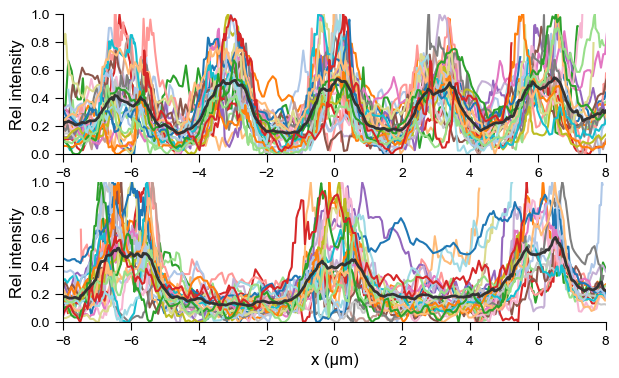

In [171]:
import numpy as np
from matplotlib import pyplot as plt
import matplotlib
plt.style.use(f"/root/shared/gitrepos/smart-mechanotransduction/plotting/smart_plots.mplstyle")
matplotlib.rcParams.update({'figure.figsize': (7,4)})
contour_list_p3 = []
contour_list_p6 = []
usetimepoint = True
timepoint = 5
xInterp = np.linspace(-11,11,551)
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=plt.colormaps['tab20'].colors)
for i in range(1,301,2):
    xVals = np.genfromtxt('/root/shared/gitrepos/smart-mechanotransduction/plotting/lamin_contours.csv',
                        delimiter=',',usecols=i)
    pitchVal = xVals[1]
    if usetimepoint:
        if xVals[2] != timepoint:
            continue
    xVals = xVals[4:]
    xVals = xVals[~np.isnan(xVals)]
    intensityVals = np.genfromtxt('/root/shared/gitrepos/smart-mechanotransduction/plotting/lamin_contours.csv',
                            delimiter=',',usecols=i+1)
    intensityVals = intensityVals[4:]
    intensityVals = intensityVals[~np.isnan(intensityVals)]
    # rescale intensity vals
    intensityVals = (intensityVals - np.min(intensityVals))/(np.max(intensityVals)-np.min(intensityVals))
    if not np.all(np.diff(xVals)>0):
        finalIdx = np.nonzero(np.diff(xVals)<=0)[0][0]
        xVals=xVals[0:finalIdx]
        intensityVals = intensityVals[0:finalIdx]
    if pitchVal == 3:
        plt.subplot(2,1,1)
        if usetimepoint:
            plt.plot(xVals, intensityVals)
        interpVals = np.interp(xInterp,xVals,intensityVals)
        interpVals[xInterp < xVals[0]] = np.nan
        interpVals[xInterp > xVals[-1]] = np.nan
        contour_list_p3.append(interpVals)
    elif pitchVal == 6:
        plt.subplot(2,1,2)
        if usetimepoint:
            plt.plot(xVals, intensityVals)
        interpVals = np.interp(xInterp,xVals,intensityVals)
        interpVals[xInterp < xVals[0]] = np.nan
        interpVals[xInterp > xVals[-1]] = np.nan
        contour_list_p6.append(interpVals)

p3Avg = np.zeros_like(xInterp)
p3Std = np.zeros_like(xInterp)
for i in range(len(xInterp)):
    curVals = []
    for j in range(len(contour_list_p3)):
        if not np.isnan(contour_list_p3[j][i]):
            curVals.append(contour_list_p3[j][i])
    p3Avg[i] = np.average(curVals)
    p3Std[i] = np.std(curVals)
plt.subplot(2,1,1)
plt.plot(xInterp, p3Avg, linewidth=2, color=[0.2,0.2,0.2])
if not usetimepoint:
    plt.plot(xInterp, p3Avg+p3Std, linewidth=1, color=[0.2,0.2,0.2])
    plt.plot(xInterp, p3Avg-p3Std, linewidth=1, color=[0.2,0.2,0.2])
    plt.fill_between(xInterp, p3Avg, p3Avg+p3Std, alpha=0.4, color=[0.2,0.2,0.2])
    plt.fill_between(xInterp, p3Avg, p3Avg-p3Std, alpha=0.4, color=[0.2,0.2,0.2])
plt.xlim([-8,8])
plt.ylim([0,1])
plt.ylabel('Rel intensity')

p6Avg = np.zeros_like(xInterp)
p6Std = np.zeros_like(xInterp)
for i in range(len(xInterp)):
    curVals = []
    for j in range(len(contour_list_p6)):
        if not np.isnan(contour_list_p6[j][i]):
            curVals.append(contour_list_p6[j][i])
    p6Avg[i] = np.average(curVals)
    p6Std[i] = np.std(curVals)
plt.subplot(2,1,2)
plt.plot(xInterp, p6Avg, linewidth=2, color=[0.2,0.2,0.2])
if not usetimepoint:
    plt.plot(xInterp, p6Avg+p6Std, linewidth=1, color=[0.2,0.2,0.2])
    plt.plot(xInterp, p6Avg-p6Std, linewidth=1, color=[0.2,0.2,0.2])
    plt.fill_between(xInterp, p6Avg, p6Avg+p6Std, alpha=0.4, color=[0.2,0.2,0.2])
    plt.fill_between(xInterp, p6Avg, p6Avg-p6Std, alpha=0.4, color=[0.2,0.2,0.2])
plt.xlim([-8,8])
plt.ylim([0,1.0])
plt.ylabel('Rel intensity')
plt.xlabel('x (µm)')
if usetimepoint:
    plt.savefig(f"aligned_profiles_t{timepoint}.pdf", format="pdf")
else:
    plt.savefig("aligned_profiles.pdf", format="pdf")

/tmp/ipykernel_223589/2028802233.py:104: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ulin.vector().set_local(cur_array[dof_map])
/tmp/ipykernel_223589/2028802233.py:106: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  alin.vector().set_local(a_array[dof_map])
/tmp/ipykernel_223589/2028802233.py:108: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  stresslin.vector().set_local(stress_array[dof_map])
/tmp/ipykernel_223589/2028802233.py:110: DeprecationWarning: Conversio

Building point search tree to accelerate distance queries.
Computed bounding box tree with 28311 nodes for 14156 points.
3234.442993764856


/tmp/ipykernel_223589/2028802233.py:104: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ulin.vector().set_local(cur_array[dof_map])
/tmp/ipykernel_223589/2028802233.py:106: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  alin.vector().set_local(a_array[dof_map])
/tmp/ipykernel_223589/2028802233.py:108: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  stresslin.vector().set_local(stress_array[dof_map])
/tmp/ipykernel_223589/2028802233.py:110: DeprecationWarning: Conversio

3653.881606748248


/tmp/ipykernel_223589/2028802233.py:104: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  ulin.vector().set_local(cur_array[dof_map])
/tmp/ipykernel_223589/2028802233.py:106: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  alin.vector().set_local(a_array[dof_map])
/tmp/ipykernel_223589/2028802233.py:108: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  stresslin.vector().set_local(stress_array[dof_map])
/tmp/ipykernel_223589/2028802233.py:110: DeprecationWarning: Conversio

4289.812809756257


ROOT -2026-09-22 21:44:41,989 fontTools.subset - INFO - maxp pruned (__init__.py:2783)
ROOT -2026-09-22 21:44:41,995 fontTools.subset - INFO - LTSH dropped (__init__.py:2767)
ROOT -2026-09-22 21:44:41,999 fontTools.subset - INFO - cmap pruned (__init__.py:2783)
ROOT -2026-09-22 21:44:42,012 fontTools.subset - INFO - kern pruned (__init__.py:2783)
ROOT -2026-09-22 21:44:42,013 fontTools.subset - INFO - post pruned (__init__.py:2783)
ROOT -2026-09-22 21:44:42,015 fontTools.subset - INFO - PCLT dropped (__init__.py:2767)
ROOT -2026-09-22 21:44:42,032 fontTools.subset - INFO - GSUB pruned (__init__.py:2783)
ROOT -2026-09-22 21:44:42,033 fontTools.subset - INFO - JSTF dropped (__init__.py:2767)
ROOT -2026-09-22 21:44:42,034 fontTools.subset - INFO - DSIG dropped (__init__.py:2767)
ROOT -2026-09-22 21:44:42,037 fontTools.subset - INFO - name pruned (__init__.py:2783)
ROOT -2026-09-22 21:44:42,055 fontTools.subset - INFO - glyf pruned (__init__.py:2783)
ROOT -2026-09-22 21:44:42,063 fontTools

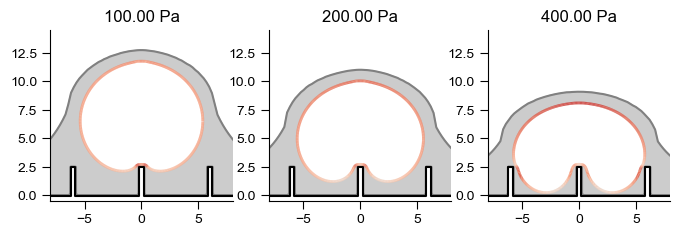

In [167]:
# mesh_num = 2
# pitchList = [5.0, 2.5, 1.0, 5.0, 2.5, 2.5] # last one is fake...
# heightList =[1.0, 1.0, 1.0, 1.0, 1.0, 0.0]
# radList = [0.1, 0.1, 0.1, 0.5, 0.25, 0.25] # last one is fake...
rNP = 0.2#radList[mesh_num]
pNP  = 6.0#6.0#pitchList[mesh_num]
hNP = 2.5#3.0#heightList[mesh_num]
laminVal = 1.5
# parent_folder = "/root/scratch/revision_coupled_nuc_sims/results_nanopillarsVaryLamin_2026-07-20"
# results_folder = f"{parent_folder}/nanopillars_r{rNP}_p{pNP}_force400.0_t0100.0_lamin{laminVal}/mech_data"
results_folder = f"/root/scratch/revision_nuconly_sims/results_nanopillars_nuconly_2026-09-14_sweep/nucmech_nanopillars_h{hNP}_p{pNP}_r{rNP}"
if hNP == 0:
    results_folder = f"/root/scratch/revision_nuconly_sims/results_nanopillars_nuconly_2026-09-21_sweep/nucmech_flat"
# results_folder = "/root/shared/gitrepos/nuc_indent_testInner_largeNP"
test_mesh_file = d.XDMFFile(f"{results_folder}/u_np_ellipsoid.xdmf")
test_mesh = d.Mesh()
test_mesh_file.read(test_mesh)

test_file_ulin = f"{results_folder}/ulin_np_ellipsoid.h5"
test_file_alin = f"{results_folder}/a_np_ellipsoid.h5"#surf_stress.h5"
test_file_stresslin = f"{results_folder}/surf_stress.h5"
test_file_tension = f"{results_folder}/surf_tension.h5"
# test_file_y = f"{results_folder}/uylin_np_ellipsoid.h5"
# test_file_z = f"{results_folder}/uzlin_np_ellipsoid.h5"

Vtest = d.VectorFunctionSpace(test_mesh, "P", 1)
Vscalar = d.FunctionSpace(test_mesh, "P", 1)
ulin = d.Function(Vtest)
alin = d.Function(Vtest)
stresslin = d.Function(Vtest)
tensionlin = d.Function(Vscalar)
# Vtest = d.FunctionSpace(test_mesh, "P", 1)
# ux = d.Function(Vtest)
# uy = d.Function(Vtest)
# uz = d.Function(Vtest)
xSubstrate = np.array([])
ySubstrate = np.array([])
xSteric = 0.2
zShift = hNP + xSteric
if hNP == 0:
    xMax = 8.5
    xSubstrate = np.array([-xMax,xMax])
    ySubstrate = np.array([hNP,hNP])
else:
    xMax = np.ceil(8.5/pNP) * pNP
    xNP = np.arange(-xMax, xMax+pNP, pNP)
    for i in range(len(xNP)):
        xCur = xNP[i] + np.array([-rNP, -rNP, rNP, rNP])
        yCur = np.array([0.0, hNP, hNP, 0.0])
        xSubstrate = np.append(xSubstrate, xCur)
        ySubstrate = np.append(ySubstrate, yCur)

pRamp = np.loadtxt(f"{results_folder}/pRamp.txt")
kRamp = np.loadtxt(f"{results_folder}/kRamp.txt")

forces = [100.0, 200.0, 400.0]#[100.0, 200.0, 400.0]# 300.0, 600.0, 900.0]
indices = []#[np.nonzero(kRamp==0.0)[0][-1]]
for i in range(len(forces)):
    if forces[i] == 0:
        indices.append(6)
    else:
        indices.append(np.argmin(np.abs(kRamp-forces[i])))
# indices = indices[1::]
# fig, ax = plt.subplots(len(indices),1,figsize=(4,8))
fig, ax = plt.subplots(1,len(indices),figsize=(8,4))
# fig, ax = plt.subplots(1,len(indices),figsize=(12,6))

for idx in range(len(indices)):#, 5, 10, 20, 50, 100, 175, 250]:
    i = indices[idx]
    # vecs = []
    # for file_name in [test_file_x, test_file_y, test_file_z]:
    #     cur_file = d.HDF5File(d.MPI.comm_world, file_name, "r")
    #     cur_array = d.Vector()
    #     cur_file.read(cur_array, f"VisualisationVector/{i}", True)
    #     cur_file.close()
    #     vecs.append(cur_array[:])
    cur_file = h5py.File(test_file_ulin, 'r')#d.HDF5File(d.MPI.comm_world, test_file_ulin, "r")
    # cur_array = d.Vector()
    # cur_file.read(cur_array, f"VisualisationVector/{i}", True)
    cur_array = cur_file['VisualisationVector'][f'{i}'][()]
    cur_array = cur_array.reshape((3*len(test_mesh.coordinates()),1))
    cur_file.close()

    a_file = h5py.File(test_file_alin, 'r')#d.HDF5File(d.MPI.comm_world, test_file_ulin, "r")
    # cur_array = d.Vector()
    # cur_file.read(cur_array, f"VisualisationVector/{i}", True)
    a_array = a_file['VisualisationVector'][f'{i}'][()]
    a_array = a_array.reshape((3*len(test_mesh.coordinates()),1))
    a_file.close()

    stress_file = h5py.File(test_file_stresslin, 'r')#d.HDF5File(d.MPI.comm_world, test_file_ulin, "r")
    stress_array = stress_file['VisualisationVector'][f'{i}'][()]
    stress_array = stress_array.reshape((3*len(test_mesh.coordinates()),1))
    stress_file.close()

    tension_file = h5py.File(test_file_tension, 'r')#d.HDF5File(d.MPI.comm_world, test_file_ulin, "r")
    tension_array = tension_file['VisualisationVector'][f'{i}'][()]
    tension_array = tension_array.reshape((len(test_mesh.coordinates()),1))
    tension_file.close()

    dof_map = d.dof_to_vertex_map(Vtest)[:]
    dof_map_scalar = d.dof_to_vertex_map(Vscalar)[:]
    # array matches mesh ordering; reorder according to dof mapping for Vcur
    ulin.vector().set_local(cur_array[dof_map])
    ulin.vector().apply("insert")
    alin.vector().set_local(a_array[dof_map])
    alin.vector().apply("insert")
    stresslin.vector().set_local(stress_array[dof_map])
    stresslin.vector().apply("insert")
    tensionlin.vector().set_local(tension_array[dof_map_scalar])
    tensionlin.vector().apply("insert")
    
    # ux.vector().set_local(vecs[0][dof_map])
    # ux.vector().apply("insert")
    # uy.vector().set_local(vecs[1][dof_map])
    # uy.vector().apply("insert")
    # uz.vector().set_local(vecs[2][dof_map])
    # uz.vector().apply("insert")

    zMax = np.max(test_mesh.coordinates()[:,2])
    zMin = np.min(test_mesh.coordinates()[:,2])
    rMax = np.max(np.sqrt(test_mesh.coordinates()[:,0]**2 + 
                        test_mesh.coordinates()[:,1]**2))
    aNuc = rMax
    zNuc = (zMax+zMin)/2
    bNuc = (zMax-zMin)/2
    assert np.abs(aNuc-bNuc) < 1e-4

    ulin.set_allow_extrapolation(True)
    alin.set_allow_extrapolation(True)
    tensionlin.set_allow_extrapolation(True)
    # uy.set_allow_extrapolation(True)
    # uz.set_allow_extrapolation(True)
    theta_sample = np.linspace(0.0, 2*np.pi, 500)
    rvals = np.zeros_like(theta_sample)
    zvals = np.zeros_like(theta_sample)
    avals = np.zeros_like(theta_sample)
    uvals = np.zeros_like(theta_sample)
    rmidvals = np.zeros_like(theta_sample)
    zmidvals = np.zeros_like(theta_sample)
    stressvals = np.zeros_like(theta_sample)
    stressvals_alt = np.zeros_like(theta_sample)
    tensionvals = np.zeros_like(theta_sample)
    for i in range(len(theta_sample)):
        rCur = bNuc*np.cos(theta_sample[i])
        rCurCalc = np.abs(rCur)
        zCur = zNuc + bNuc*np.sin(theta_sample[i])
        uCur = ulin(rCurCalc, 0.0, zCur)
        # uzCur = uz(rCurCalc, 0.0, zCur)
        rvals[i] = rCur + np.sign(rCur)*uCur[0]
        zvals[i] = zCur + uCur[2]
        thickness = 0.2
        rCur_aCalc = np.abs((bNuc-thickness)*np.cos(theta_sample[i]))
        zCur_aCalc = zNuc + (bNuc-thickness)*np.sin(theta_sample[i])
        avals[i] = np.sqrt(np.sum((alin(rCur_aCalc, 0.0, zCur_aCalc))**2))
        uvals[i] = np.sqrt(np.sum((uCur)**2))
        rCur_stressCalc = np.abs((bNuc-3*thickness/4)*np.cos(theta_sample[i]))
        zCur_stressCalc = zNuc + (bNuc-3*thickness/4)*np.sin(theta_sample[i])
        rCur_outer = np.abs((bNuc)*np.cos(theta_sample[i]))
        zCur_outer = zNuc + (bNuc)*np.sin(theta_sample[i])
        rmidCur = (bNuc-thickness/2)*np.cos(theta_sample[i])
        rmidCurCalc = np.abs(rmidCur)
        zmidCur = zCur_stressCalc
        umidCur = ulin(rmidCurCalc, 0.0, zmidCur)
        rmidvals[i] = rmidCur + np.sign(rmidCur)*umidCur[0]
        zmidvals[i] = zCur_stressCalc + umidCur[2]
        stressvals[i] = np.sqrt(np.sum((stresslin(rCur_stressCalc, 0.0, zCur_stressCalc))**2))
        stressvals_alt[i] = np.sqrt(np.sum((stresslin(rCur_aCalc, 0.0, zCur_aCalc))**2))
        tensionvals[i] = 0.05*tensionlin(rCur_outer, 0.0, zCur_outer)/2000
    
    if hNP == 0:
        rvalsPM = np.array([0.0, 2*rMax])
        zvalsPM = np.array([hNP, hNP])
    else:
        rvalsPM = np.array([0.0])
        zvalsPM = np.array([hNP])
        while rvalsPM[-1] < 2*rMax:
            rStart = rvalsPM[-1]
            thetaDown1 = np.linspace(0.0, np.pi/2, 10)
            rCurvDown1 = rStart + rNP + 0.05*np.sin(thetaDown1)
            zCurvDown1 = hNP + 0.05*(np.cos(thetaDown1)-1)
            thetaDown2 = np.linspace(np.pi/2, 0.0, 10)
            rCurvDown2 = rStart + rNP + 0.05 + 0.2*(1-np.sin(thetaDown2))
            zCurvDown2 = 0.2*(1-np.cos(thetaDown2))
            thetaUp1 = np.linspace(0.0, -np.pi/2, 10)
            rCurvUp1 = rStart+pNP - rNP - 0.05 - 0.2*(1+np.sin(thetaUp1))
            zCurvUp1 = 0.2*(1-np.cos(thetaUp1))
            thetaUp2 = np.linspace(-np.pi/2, 0.0, 10)
            rCurvUp2 = rStart+pNP - rNP + 0.05*np.sin(thetaUp2)
            zCurvUp2 = hNP + 0.05*(np.cos(thetaUp2)-1)

            rvalsPM = np.concatenate((rvalsPM, rCurvDown1, rCurvDown2, rCurvUp1, rCurvUp2, np.array([rStart+pNP])))
            zvalsPM = np.concatenate((zvalsPM, zCurvDown1, zCurvDown2, zCurvUp1, zCurvUp2, np.array([hNP])))
    rvalsPM = np.concatenate((-rvalsPM[-1::-1], rvalsPM))
    zvalsPM = np.concatenate((zvalsPM[-1::-1], zvalsPM))
    rFake = np.linspace(np.min(rvalsPM), np.max(rvalsPM), 100)
    startSample = np.argmax(rvals)
    endSample = np.argmin(rvals)
    zFake = np.zeros_like(rFake)
    for i in range(len(rFake)):
        avgWindowHalf = 10
        if startSample < endSample:
            curSample = np.argmin(np.abs(rFake[i]-1.2*rvals[startSample+1:endSample]))
            zFake[i] = zvals[curSample+startSample+1] +zShift + 1
            avgIdx = range(curSample+startSample+1-avgWindowHalf,
                           curSample+startSample+2+avgWindowHalf)
        else:
            curSample = np.argmin(np.abs(rFake[i]-1.2*np.concatenate((rvals[0:endSample], rvals[startSample:]))))
            if curSample < endSample:
                zFake[i] = zvals[curSample] + zShift + 1
                avgIdx = range(curSample-avgWindowHalf,curSample+1+avgWindowHalf)
            else:
                zFake[i] = zvals[curSample-endSample+startSample] + zShift + 1
                avgIdx = range(curSample-endSample+startSample-avgWindowHalf,
                               curSample-endSample+startSample+1+avgWindowHalf)
        if np.abs(rFake[i]) < 5*rNP:
            zFake[i] = np.average(zvals[avgIdx]) + zShift + 1
        elif np.abs(rFake[i]) > 1.2*np.max(rvals):
            zlin = zFake[i]*(1 - (np.abs(rFake[i])-1.2*np.max(rvals))/8)
            zFake[i] = ((zFake[i] + zlin)/2)*(4/(4+np.abs(rFake[i])-1.2*np.max(rvals)))
    rvalsPM = np.concatenate((rFake[-1::-1], rvalsPM))
    zvalsPM = np.concatenate((zFake[-1::-1], zvalsPM))

    ax[idx].plot(rvalsPM, zvalsPM, linewidth=1.5, color=[0.5,0.5,0.5])
    ax[idx].fill(rvalsPM, zvalsPM, color=[0.8,0.8,0.8])
    ax[idx].plot(xSubstrate, ySubstrate-0.05, color='k', linewidth=1.5)
    ax[idx].fill(rvals, zvals+zShift, color='w')
    line = colored_line(rvals, zvals+zShift, avals, ax[idx], linewidth=2, cmap='coolwarm')
    # line = colored_line(rvals, zvals+zShift, np.ones_like(stressvals), ax[idx], linewidth=1, cmap='coolwarm')
    # line = colored_line(rmidvals, zmidvals+zShift, stressvals, ax[idx], linewidth=1, cmap='coolwarm')

    # ax[idx].plot(rvals, zvals)
    # line.set_clim([1, 2])#10000])
    line.set_clim([0.5,2.2])
    # line.set_clim([0, 5.0])
    # print(np.max(uvals))
    # line.set_clim([0.0, 2000])
    # line = colored_line(rvals, zvals+zShift, stressvals, ax[idx], linewidth=2, cmap='coolwarm')
    ax[idx].set_xlim([-8, 8])
    ax[idx].set_ylim([-0.5, 14.5])
    # ax[idx].set_xlim([-1, 1])
    # ax[idx].set_ylim([-0.1, 1])
    ax[idx].set_aspect("equal")
    ax[idx].set_title(f"{kRamp[indices[idx]]:.2f} Pa")
    # print(min(avals))
    # print(max(avals))
    print(np.average(stressvals))

# plt.colorbar(line)
plt.savefig(f"nuc_indent_r{rNP}_p{pNP}_h{hNP}.pdf", format="pdf")
# plt.savefig(f"nuc_indent_lamin{laminVal}.pdf", format="pdf")

In [ ]:

rNP = 0.35#radList[mesh_num]
pNP  = 3.0#6.0#pitchList[mesh_num]
hNP = 3.0#3.0#heightList[mesh_num]
results_folder = f"/root/scratch/revision_nuconly_sims/results_nanopillars_nuconly_2026-09-14_sweep/nucmech_nanopillars_h{hNP}_p{pNP}_r{rNP}"
if hNP == 0:
    results_folder = f"/root/scratch/revision_nuconly_sims/results_nanopillars_nuconly_2026-09-14_sweep/nucmech_flat"
test_file_tension = f"{results_folder}/surf_tension.h5"
pRamp = np.loadtxt(f"{results_folder}/pRamp.txt")
kRamp = np.loadtxt(f"{results_folder}/kRamp.txt")
vols = np.loadtxt(f"{results_folder}/vol_inner.txt")
SAs = np.loadtxt(f"{results_folder}/outer_SA.txt")
# tension_file = h5py.File(test_file_tension, 'r')#d.HDF5File(d.MPI.comm_world, test_file_ulin, "r")
# tensions = np.zeros_like(pRamp)
# for i in range(len(kRamp)):
#     tension_array = tension_file['VisualisationVector'][f'{i}'][()]
#     tensions[i] = np.average(tension_array)
# tension_file.close()
# plt.plot(kRamp[6:], pRamp[6:])
# plt.plot(vols[7:], pRamp[7:-1])
load_data = np.loadtxt('new_yaptaz_nanopillar_data.csv', skiprows=1, delimiter=',')
avg_NC_ratio = np.average(load_data[:,2]/load_data[:,4])
vol_ref = 10.05
vol0_nuc = 142.0 + vol_ref # this includes the NE + lamina
R0 = ((3/(4*np.pi))*(vol0_nuc-vol_ref))**(1/3)
vol_tot = (vols[6]+vol_ref) / avg_NC_ratio
baselineOsmotic = 2400
vol0_cyto = vol_tot - vol0_nuc
vol_excl_nuc = (vol0_nuc-vol_ref)*0.01
vol_excl_cyto = vol0_cyto*0.02
pressBoosts = [0.0, 30.0, 100.0]#, 300.0, 1000.0]
pressCharges = [0.0, 300.0, 300.0]
for i in range(len(pressBoosts)):
    pressBoost = pressBoosts[i]
    pressCharge = pressCharges[i]
    pMax = 820.0
    fracOsmotic = (pMax-pressBoost-pressCharge)/pMax
    nucSoluteFactor = (fracOsmotic*pMax + baselineOsmotic) * (vol0_nuc - vol_ref - vol_excl_nuc) 
    nucBoostFactor = (pressBoost) * (vol0_nuc - vol_ref) * (R0**(15/4))
    cytoSoluteFactor = (baselineOsmotic) * (vol0_cyto - vol_excl_cyto)
    nucChargeFactor = (pressCharge) * (vol0_nuc - vol_ref)**2
    # compute pressure
    cytoVol = vol_tot - vols - vol_ref
    Reff = ((3/(4*np.pi))*vols)**(1/3)
    pNuc = nucSoluteFactor/(vols-vol_excl_nuc) + nucBoostFactor/(vols*Reff**(15/4)) + nucChargeFactor/(vols**2)
    pCyto = cytoSoluteFactor/(cytoVol - vol_excl_cyto)
    # plt.plot(pNuc[6:]-pCyto[6:])
    # plt.plot(pRamp[6:])
    # fig, ax1 = plt.subplots(figsize=(7,2.5))
    # ax1.plot(kRamp[7:-1], 4*vols[7:])
    # plt.xlabel('Cap stress (Pa)')
    # plt.ylabel('Nuclear volume')
    # ax2 = ax1.twinx()
    # ax2.plot(kRamp[7:-1], pRamp[7:-1])
    # plt.ylabel('Osmotic pressure gradient (Pa)')
    # plt.xlim([0, 1000])
    # plt.savefig(f"nuc_indent_r{rNP}_p{pNP}_h{hNP}_pressVol.pdf", format="pdf")
    plt.plot(vols[7:], pNuc[7:]-pCyto[7:], label=f'Chromatin confinement stress = {pressBoost} Pa')

plt.xlabel('Nuclear volume')
plt.ylabel('Pressure difference across NE (Pa)')
plt.legend()
plt.savefig(f"pressWithChromatin.pdf", format="pdf")
# ax1.plot(kRamp[7:-1], SAs[7:])
# plt.xlabel('Cap stress (Pa)')
# plt.ylabel('NE surface area')
# ax2 = ax1.twinx()
# ax2.plot(kRamp[7:], 0.05*tensions[7:]/2000)
# plt.ylabel('Average NE tension (mN/m)')
# plt.xlim([0, 1000])
# plt.savefig(f"nuc_indent_r{rNP}_p{pNP}_h{hNP}_areaTension.pdf", format="pdf")

KeyboardInterrupt: 

In [ ]:
from matplotlib import font_manager
font_files = font_manager.findSystemFonts(fontpaths=None, fontext="ttf")
print(font_files)

In [ ]:
matplotlib.rcParams.update({'figure.figsize': (6,3)})
tvec = np.linspace(0.0, 500.0, 100)
force = 300.0 + 600.0*(1-np.exp(-tvec/100.0))
plt.plot(tvec, force)
# plt.ylim([0, 900.0])
plt.xlim([-50.0, 550.0])
plt.xlabel('Time (s)')
plt.ylabel('Cap stress (Pa)')
# plt.savefig("force_dyn.pdf", format="pdf")

In [ ]:
fig, ax = plt.subplots(2,1,figsize=(6,3))
# ax2 = ax1.twinx() 
kRamp = np.loadtxt(f"{results_folder}/kRamp.txt")
pRamp = np.loadtxt(f"{results_folder}/pRamp.txt")
forceMax = 1000.0
force0 = 245.0
time = -100.0*np.log(((forceMax-force0) - (kRamp-force0))/(forceMax-force0))
ax[0].plot(time, kRamp)
plt.ylim([0, 1000])
ax[1].plot(time, pRamp)
plt.ylim([750,950])
plt.savefig("press_and_force_dyn.pdf", format="pdf")

Building point search tree to accelerate distance queries.
Computed bounding box tree with 22127 nodes for 11064 points.
8
18
28
38
48
58
68
78
88
98
108
118
128
138
148
158
168
178
188
198
206
Building point search tree to accelerate distance queries.
Computed bounding box tree with 22127 nodes for 11064 points.
8
18
28
38
48
58
68
78
88
98
108
118
128
138
148
158
168
178
188
198
203


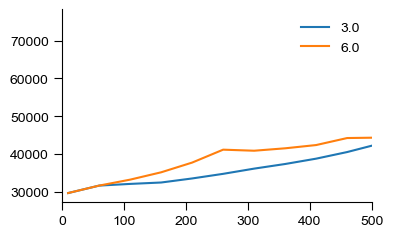

In [163]:
matplotlib.rcParams.update({'figure.figsize': (4,2.5)})
radVec = [0.35]#[0.0, 0.35]#, 0.5]#, 0.5]#, 0.2]#, 0.1]
pitchVec = [3.0,6.0]#[1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0, 6.5, 7.0, 7.5, 8.0]
height = 3.0
outputStress = []
outputStretch = []
outputTension = []
outputHeight = []
outputFlattening = []
outputIndentation = []
outputFlatteningDyn = []
outputIndentationDyn = []
outputRamps = []
testSelForce = False
dynSp = 10
for rads in radVec:
    forceVals = [100,200,400]#np.linspace(20.0, 500.0, 25)
    avgStress = np.zeros((len(forceVals), len(pitchVec)))
    maxStress = np.zeros((len(forceVals), len(pitchVec)))
    avgStretch = np.zeros((len(forceVals), len(pitchVec)))
    maxStretch = np.zeros((len(forceVals), len(pitchVec)))
    indentation = np.zeros((len(forceVals), len(pitchVec)))
    compression = np.zeros((len(forceVals), len(pitchVec)))
    aspectRatio = np.zeros((len(forceVals), len(pitchVec)))
    deformRad = np.zeros((len(forceVals), len(pitchVec)))
    contactForce = np.zeros((len(forceVals), len(pitchVec)))
    tension = np.zeros((len(forceVals), len(pitchVec)))
    if rads == 0:
        pitchIt = [0]
    else:
        pitchIt = range(len(pitchVec))
    for m in pitchIt:
        # mesh_num = mesh_vec[m]
        # results_folder = f"/root/scratch/nuc_mechanics_data/results_nanopillars_nuconly_2025-09-29_REDO/nucmech_mesh{mesh_num}"
        if rads==0:
            results_folder = f"/root/scratch/revision_nuconly_sims/results_nanopillars_nuconly_2026-09-14_sweep/nucmech_flat"
        else:
            # results_folder = f"/root/scratch/revision_nuconly_sims/results_nanopillars_nuconly_2026-09-14_sweep/nucmech_nanopillars_h{height}_p{pitchVec[m]}_r{rads}"
            results_folder = f"/root/scratch/revision_nuconly_sims/results_nanopillars_nuconly_2026-09-21_sweep/nucmech_nanopillars_h{height}_p{pitchVec[m]}_r{rads}"
            # parent_folder = "/root/scratch/nuc_mechanics_data/results_nanopillars_2025-12-21"
            # parent_folder = f"{parent_folder}_noCycle"
            # results_folder = (f"{parent_folder}/nanopillars_r{rads}_p{pitchVec[m]}_"
            #             f"force800.0_t01000.0_diff0.001_actin20.0/mech_data")

        test_mesh_file = d.XDMFFile(f"{results_folder}/u_np_ellipsoid.xdmf")
        test_mesh = d.Mesh()
        test_mesh_file.read(test_mesh)
        dxCur = d.Measure("dx", domain=test_mesh)
        vol = d.assemble(1.0*dxCur)
        z0 = min(test_mesh.coordinates()[:,2])

        Vtest = d.VectorFunctionSpace(test_mesh, "P", 1)
        Vscalar = d.FunctionSpace(test_mesh, "P", 1)
        Vtensor = d.TensorFunctionSpace(test_mesh, "P", 1)
        ulin = d.Function(Vtest)
        alin = d.Function(Vtest)
        stresslin = d.Function(Vtest)
        tensionlin = d.Function(Vscalar)
        dof_map = d.dof_to_vertex_map(Vtest)[:]
        dof_map_scalar = d.dof_to_vertex_map(Vscalar)[:]

        kRamp = np.loadtxt(f"{results_folder}/kRamp.txt")
        kLogic = kRamp > 0.0
        aMed = []
        aLower = []
        aUpper = []
        contactForceDyn = []
        contactRadDyn = []
        indentationDyn = []
        aspectRatioDyn = []
        heightDyn = []
        stretchDyn = []
        tensionDyn1 = []
        tensionDyn2 = []
        sel_idx = []
        if testSelForce:
            for forceVal in forceVals:
                sel_idx.append(np.argmin((np.array(kRamp)-forceVal)**2))
                if (kRamp[sel_idx[-1]]-forceVal)**2 > 0.1:
                    print("Warning: Force not found for this dataset")
            kRampIdx = sel_idx
        else:
            kRampIdx = np.arange(8, len(kRamp), dynSp)
            if kRampIdx[-1] < len(kRamp)-1:       
                kRampIdx = np.concatenate((kRampIdx, [len(kRamp)-1]))
            for forceVal in forceVals:
                sel_idx.append(np.argmin((np.array(kRamp[kRampIdx])-forceVal)**2))
            sel_idx = kRampIdx[sel_idx]
        for i in kRampIdx:
            # if kRamp[i] > forceVal and i > sel_idx:
            #     i -= 1
            #     break
            if np.any(sel_idx==i):
                cur_idx = np.nonzero(np.array(sel_idx)==i)[0][0]
            else:
                cur_idx = 0
            forceVal = forceVals[cur_idx]
            u_file = h5py.File(f"{results_folder}/ulin_np_ellipsoid.h5", 'r')
            a_file = h5py.File(f"{results_folder}/a_np_ellipsoid.h5", 'r')
            stress_file = h5py.File(f"{results_folder}/surf_stress.h5", 'r')
            vonmises_file = h5py.File(f"{results_folder}/vonmises_stress.h5", 'r')
            tension_file = h5py.File(f"{results_folder}/surf_tension.h5", 'r')
            try:
                u_array = u_file['VisualisationVector'][f'{i}'][()]
                a_array = a_file['VisualisationVector'][f'{i}'][()]
                stress_array = stress_file['VisualisationVector'][f'{i}'][()]
                vonmises_array = vonmises_file['VisualisationVector'][f'{i}'][()]
                tension_array = tension_file['VisualisationVector'][f'{i}'][()]
            except:
                u_file.close()
                a_file.close()
                stress_file.close()
                vonmises_file.close()
                tension_file.close()
                break

            ulin.vector().set_local(u_array.flatten()[dof_map])
            ulin.vector().apply("insert")
            ulin.set_allow_extrapolation(True)
            tensionlin.vector().set_local(tension_array.flatten()[dof_map_scalar])
            tensionlin.vector().apply("insert")
            tensionlin.set_allow_extrapolation(True)

            # I = d.variable(d.Identity(3))             # Identity tensor
            # F = d.variable(I + d.grad(ulin))             # Deformation gradient
            # C = d.variable(F.T*F)                   # Right Cauchy-Green tensor
            # I1 = d.variable(d.tr(C))
            # I2 = d.variable(0.5*(I1**2 - d.tr(C*C)))
            # J  = d.variable(d.det(F))
            # Stored strain energy density (incompressible Mooney Rivlin model)
            # psi = (mu/2)*(I1 - 3) - mu*ln(J) + (lmbda/2)*(ln(J))**2
            # psi = d.variable(5000*(I1-3) + 1000*(I2-3)) # - p*(J-1)
            # Ttensor = d.dot(F, d.diff(psi, F))/J # Cauchy stress tensor
            
            # von_mises = d.sqrt((Ttensor[0,0] - Ttensor[1,1])**2 + (Ttensor[0,0] - Ttensor[1,1])**2 + (Ttensor[0,0] - Ttensor[1,1])**2
            #              + 6*(Ttensor[0,1]**2 + Ttensor[0,2]**2 + Ttensor[2,1]**2))/np.sqrt(2)
            # von_mises = d.project(von_mises, Vscalar)
            # Tlin = d.project(Ttensor, Vtensor)
            # p1 = np.zeros_like(von_mises.vector()[:])
            # p2 = np.zeros_like(von_mises.vector()[:])
            # p3 = np.zeros_like(von_mises.vector()[:])
            # Tvec = Tlin.vector()[:]
            # for idx in range(len(p1)):
            #     cur_array = Tvec[9*idx:9*(idx+1)].reshape((3,3))
            #     eigcalc = np.linalg.eig(cur_array)
            #     eigvals = np.sort(eigcalc.eigenvalues)
            #     p1[idx] = eigvals[2]
            #     p2[idx] = eigvals[1]
            #     p3[idx] = eigvals[0]

            thickness = 0.2
            zCenter = (z0+thickness) + ulin(0,0,z0+thickness)[2]
            zCenterOuter = z0 + ulin(0,0,z0)[2]
            alin.vector().set_local(a_array.flatten()[dof_map])
            alin.vector().apply("insert")
            stresslin.vector().set_local(stress_array.flatten()[dof_map])
            stresslin.vector().apply("insert")
            stresslin.set_allow_extrapolation(True)

            # sample values over a sphere
            mf2 = d.MeshFunction("size_t", test_mesh, 2, 0)
            nucRad1 = 4.1
            nucRad2 = 4.1
            class OuterSurf(d.SubDomain):
                def inside(self, x, on_boundary):
                    bound_val = pow(pow(x[0]/nucRad1,2) + pow(x[1]/nucRad1,2) + 
                                pow((x[2]-nucRad2-z0)/nucRad2,2),0.5)
                    cutoffFrac = 0.99
                    return bound_val > cutoffFrac and on_boundary
            outerSurf = OuterSurf()
            outerSurf.mark(mf2, 10)
            outer_mesh = d.create_meshview(mf2, 10)
            inner_stress_vals = []
            Vouter = d.VectorFunctionSpace(outer_mesh, "P", 1)
            surf_stress = d.Function(Vouter)
            stressvals = surf_stress.vector()[:]
            for cidx in range(0,len(Vouter.tabulate_dof_coordinates()),3):
                coords = Vouter.tabulate_dof_coordinates()[cidx]
                Rcur = np.sqrt(coords[0]**2 + coords[1]**2 + (coords[2]-z0-nucRad2)**2)
                Rscale = (Rcur-thickness/2)/Rcur
                xTest = coords[0]*Rscale
                yTest = coords[1]*Rscale
                zTest = z0+nucRad2 + (coords[2]-z0-nucRad2)*Rscale
                aCur = alin(xTest,yTest,zTest)
                stressvals[cidx:cidx+3] = stresslin(xTest,yTest,zTest)*np.sqrt(aCur[0]**2+aCur[1]**2+aCur[2]**2)
            surf_stress.vector().set_local(stressvals)
            surf_stress.vector().apply("insert")

            Vouter_scalar = d.FunctionSpace(outer_mesh, "P", 1)
            surf_tension = d.Function(Vouter_scalar)
            surf_tension_vals = surf_tension.vector()[:]
            surf_tension_vals_lamin = np.zeros_like(surf_tension_vals)
            for cidx in range(0,len(Vouter_scalar.tabulate_dof_coordinates()),3):
                coords = Vouter_scalar.tabulate_dof_coordinates()[cidx]
                Rcur = np.sqrt(coords[0]**2 + coords[1]**2 + (coords[2]-z0-nucRad2)**2)
                Rscale = (Rcur-.025)/Rcur # evaluate at the midplane of the NE membranes
                Rscale2 = (Rcur-0.1)/Rcur # midpoint of entire NE
                xTest = coords[0]*Rscale
                yTest = coords[1]*Rscale
                zTest = z0+nucRad2 + (coords[2]-z0-nucRad2)*Rscale
                xTest2 = coords[0]*Rscale2
                yTest2 = coords[1]*Rscale2
                zTest2 = z0+nucRad2 + (coords[2]-z0-nucRad2)*Rscale2
                aCur = alin(xTest,yTest,zTest)
                surf_tension_vals[cidx] = tensionlin(xTest,yTest,zTest) # NEEDS TO CONVERSION TO BE USED IN INTEGRALS!!
                surf_tension_vals_lamin[cidx] = tensionlin(xTest2,yTest2,zTest2)
            surf_tension.vector().set_local(surf_tension_vals)
            surf_tension.vector().apply("insert")


            # F = d.Identity(3) + d.grad(ulin)             # Deformation gradient
            # J  = d.det(F)
            int_midplane = d.MeshFunction("size_t", outer_mesh, 2, 0)
            for f in d.faces(outer_mesh):
                for v in d.vertices(f):
                    curCoord = outer_mesh.coordinates()[v.index()]
                    if (curCoord[2] + ulin(curCoord)[2]) <= (zCenter+0.05):
                        int_midplane[f] = 1
            dxMidplane = d.Measure("dx", domain=outer_mesh, subdomain_data=int_midplane)

            stressmag = d.sqrt(stresslin[0]**2 + stresslin[1]**2 + stresslin[2]**2)
            stretchmag = d.sqrt(alin[0]**2 + alin[1]**2 + alin[2]**2)
            deformCoord = test_mesh.coordinates() + u_array
            deformOuterCoord = deformCoord[outer_mesh.topology().mapping()[test_mesh.id()].vertex_map()]
            int_domain = d.MeshFunction("size_t", test_mesh, 2, 0)
            lowestInner = np.inf
            for f in d.faces(test_mesh):
                for v in d.vertices(f):
                    Rcur = np.sqrt(v.x(0)**2 + v.x(1)**2 + (v.x(2)-4.1-z0)**2)
                    if Rcur > 4.1-thickness+0.01:
                        int_domain[f] = 0
                        break
                    elif deformCoord[v.index(),2] <= (zCenter+0.05):
                        int_domain[f] = 1
                        lowestInner = min([deformCoord[v.index(),2], lowestInner])
            int_outer = d.MeshFunction("size_t", outer_mesh, 2, 0)
            for f in d.faces(outer_mesh):
                for v in d.vertices(f):
                   if deformOuterCoord[v.index(),2] <= (zCenterOuter+0.05):
                        int_outer[f] = 1
            dsCur = d.Measure("ds", domain=test_mesh, subdomain_data=int_domain)
            dsOuter = d.Measure("ds", domain=outer_mesh, subdomain_data=int_outer)
            contactForceDyn.append(max(np.sqrt(stress_array[:,0]**2+stress_array[:,1]**2+stress_array[:,2]**2)))#d.assemble(stressmag*dsCur(1)))
            indentationDyn.append(zCenter - lowestInner)
            if indentationDyn[-1] < 0.0:
                indentationDyn[-1] = 0.0
            rvals = np.sqrt(deformCoord[:,0]**2 + deformCoord[:,1]**2)
            deformLogic = deformCoord[:,2] <= (zCenter+0.05)
            if sum(deformLogic)==0:
                contactRadDyn.append(0)
            else:
                contactRadDyn.append(np.max(rvals[deformLogic]))
            aspectRatioDyn.append(2*np.max(rvals)/(np.max(deformCoord[:,2]) - np.min(deformCoord[:,2])))
            heightDyn.append(np.max(deformCoord[:,2]) - np.min(deformCoord[:,2]))
            # contactRadDyn.append(np.max(rvals))
            if d.assemble(1.0*dsCur(1)) > 0:
                # stretchDyn.append(np.max(np.sqrt(a_array[:,0]**2+a_array[:,1]**2+a_array[:,2]**2)))
                stretchDyn.append(d.assemble(stretchmag*dsCur(1))/d.assemble(1.0*dsCur(1)))
            else:
                stretchDyn.append(0)
            tensionDyn1.append(np.max(surf_tension_vals))
            tensionDyn2.append(np.max(surf_tension_vals_lamin))
            u_file.close()
            a_file.close()
            stress_file.close()
            vonmises_file.close()
            tension_file.close()

            # if i == sel_idx and forceFound:
            avgStress[cur_idx][m] = (d.assemble(stressmag*dxCur)/vol)
            stressvals = np.sqrt(stress_array[:,0]**2+stress_array[:,1]**2+stress_array[:,2]**2)
            surf_stress_mag = d.sqrt(surf_stress[0]**2 + surf_stress[1]**2 + surf_stress[2]**2)
            maxStress[cur_idx][m] = d.assemble(surf_stress_mag*dxMidplane)#/d.assemble(1.0*dxMidplane)#.vector()[:])#np.max(stressvals)
            avgStretch[cur_idx][m] = d.assemble(stretchmag*dsCur(1))/d.assemble(1.0*dsCur(1))#d.assemble(stretchmag*dxCur)/vol)
            maxStretch[cur_idx][m] = np.max(np.sqrt(a_array[:,0]**2+a_array[:,1]**2+a_array[:,2]**2))
            contactForce[cur_idx][m] = d.assemble(stressmag*dsCur(1))
            indentation[cur_idx][m] = zCenter - lowestInner
            compression[cur_idx][m] = np.max(deformCoord[:,2]) - np.min(deformCoord[:,2])
            aspectRatio[cur_idx][m] = 2*np.max(rvals)/(np.max(deformCoord[:,2]) - np.min(deformCoord[:,2]))
            deformRad[cur_idx][m] = np.max(rvals[deformLogic])
            tension[cur_idx][m] = np.max(surf_tension_vals) # NEEDS TO CONVERSION TO BE USED IN INTEGRALS!!
            # tension[cur_idx][m] = d.assemble(surf_tension*dsOuter(1))/d.assemble(1.0*dsOuter(1)) # approximation!!!
            print(i)
        if not testSelForce:
            plt.plot(kRamp[kRampIdx], np.array(tensionDyn1), label=f"{pitchVec[m]}")#np.array(aspectRatioDyn), label=f"{pitchVec[m]}")
            outputFlatteningDyn.append(aspectRatioDyn)
            outputIndentationDyn.append(indentationDyn)
            outputRamps.append(kRamp[kRampIdx])
            plt.xlim([0,500.0])
        # plt.ylim([1.5,2.5])
    
    
    if testSelForce:
        plt.plot(np.array(pitchVec), aspectRatio[1][:])#avgStretch[1][:])
    plt.legend()
    outputStretch.append(avgStretch)
    outputStress.append(maxStress)
    outputTension.append(tension)
    outputHeight.append(compression)
    outputFlattening.append(aspectRatio)
    outputIndentation.append(indentation)
    # plt.xlabel('Pitch (microns)')
    # plt.ylabel('Contact force (nN)')
    # plt.ylabel('Contact radius (µm)')
    # plt.ylabel('Avg stress (kPa)')
    # plt.xlabel('Cap stress (Pa)')
    # plt.ylabel('Deformed area force (nN)')
    # plt.savefig("deformed_force.pdf", format="pdf")
# plt.savefig("flattening_dynamics.pdf", format="pdf")

In [ ]:
strings = ["flat", "p1.5", "p3.0", "p4.5", "p6.0"]
for i in range(len(outputRamps)):
    plt.plot(outputRamps[i], outputFlatteningDyn[i], label=strings[i])
plt.xlim([0,500])
plt.ylim([1, 1.75])
plt.xlabel('Cap stress (Pa)')
plt.ylabel('Nucl. flattening index')
plt.legend()
plt.savefig("flattening_dynamics.pdf", format="pdf")

ROOT -2026-09-22 14:21:19,938 fontTools.subset - INFO - maxp pruned (__init__.py:2783)
ROOT -2026-09-22 14:21:19,939 fontTools.subset - INFO - LTSH dropped (__init__.py:2767)
ROOT -2026-09-22 14:21:19,940 fontTools.subset - INFO - cmap pruned (__init__.py:2783)
ROOT -2026-09-22 14:21:19,943 fontTools.subset - INFO - kern pruned (__init__.py:2783)
ROOT -2026-09-22 14:21:19,944 fontTools.subset - INFO - post pruned (__init__.py:2783)
ROOT -2026-09-22 14:21:19,945 fontTools.subset - INFO - PCLT dropped (__init__.py:2767)
ROOT -2026-09-22 14:21:19,947 fontTools.subset - INFO - GSUB pruned (__init__.py:2783)
ROOT -2026-09-22 14:21:19,948 fontTools.subset - INFO - JSTF dropped (__init__.py:2767)
ROOT -2026-09-22 14:21:19,949 fontTools.subset - INFO - DSIG dropped (__init__.py:2767)
ROOT -2026-09-22 14:21:19,950 fontTools.subset - INFO - name pruned (__init__.py:2783)
ROOT -2026-09-22 14:21:19,954 fontTools.subset - INFO - glyf pruned (__init__.py:2783)
ROOT -2026-09-22 14:21:19,956 fontTools

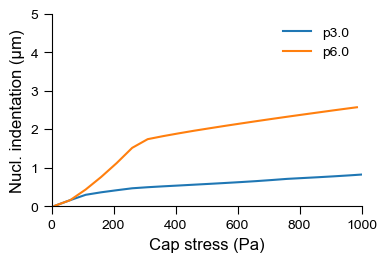

In [166]:
strings = ['p3.0', 'p6.0'] #["flat", "p1.5", "p3.0", "p4.5", "p6.0"]
for i in range(len(outputRamps)):
    plt.plot(outputRamps[i], outputIndentationDyn[i], label=strings[i])
plt.xlim([0,1000])
plt.ylim([0, 5.0])
plt.xlabel('Cap stress (Pa)')
plt.ylabel('Nucl. indentation (µm)')
plt.legend()
plt.savefig("indentation_dynamics.pdf", format="pdf")

In [ ]:
# find critical spacings
outputStretch = np.array(outputStretch)
for it in [1,2]:#range(len(outputStretch)):
    pCrit = []
    for i in range(outputStretch.shape[1]):
        pCrit.append(pitchVec[np.argmax(outputStretch[it][i])])
    plt.plot(forceVals, pCrit)
plt.ylim([2.0, 6.5])
plt.xlabel("Cap stress (Pa)")
plt.ylabel("Critical pitch (µm)")
plt.savefig("pCrit.pdf", format="pdf")

ROOT -2026-09-22 14:03:26,926 fontTools.subset - INFO - maxp pruned (__init__.py:2783)
ROOT -2026-09-22 14:03:26,927 fontTools.subset - INFO - LTSH dropped (__init__.py:2767)
ROOT -2026-09-22 14:03:26,928 fontTools.subset - INFO - cmap pruned (__init__.py:2783)
ROOT -2026-09-22 14:03:26,932 fontTools.subset - INFO - kern pruned (__init__.py:2783)
ROOT -2026-09-22 14:03:26,933 fontTools.subset - INFO - post pruned (__init__.py:2783)
ROOT -2026-09-22 14:03:26,933 fontTools.subset - INFO - PCLT dropped (__init__.py:2767)
ROOT -2026-09-22 14:03:26,935 fontTools.subset - INFO - GSUB pruned (__init__.py:2783)
ROOT -2026-09-22 14:03:26,936 fontTools.subset - INFO - JSTF dropped (__init__.py:2767)
ROOT -2026-09-22 14:03:26,936 fontTools.subset - INFO - DSIG dropped (__init__.py:2767)
ROOT -2026-09-22 14:03:26,938 fontTools.subset - INFO - name pruned (__init__.py:2783)
ROOT -2026-09-22 14:03:26,944 fontTools.subset - INFO - glyf pruned (__init__.py:2783)
ROOT -2026-09-22 14:03:26,947 fontTools

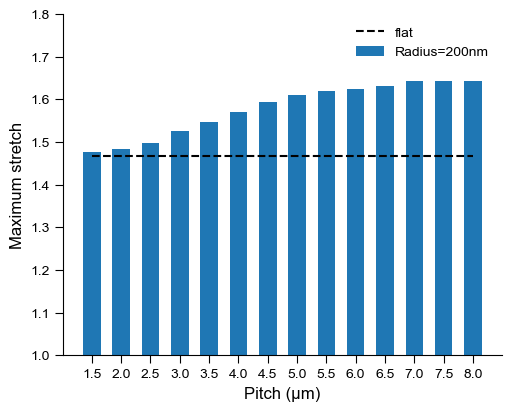

In [160]:
plot_idx = 2
curOutput = outputStretch
np_means = {
    'Radius=200nm': np.array(curOutput[1][plot_idx]),
    # 'Radius=500nm': np.array(curOutput[2][plot_idx]),
}
width = 0.6
x = np.arange(len(curOutput[0][0]))#[::2]))  # the label locations
multiplier = 0
fig, ax = plt.subplots(layout='constrained', figsize=(5,4))
for attribute, measurement in np_means.items():
    offset = width * multiplier
    rects = ax.bar(x + offset, measurement, width, label=attribute)#, hatch='///')
    # ax.bar_label(rects, padding=3)
    multiplier += 1
ax.set_ylabel('Maximum stretch')
ax.set_xticks(x, pitchVec)#[::2])
ax.set_xlabel('Pitch (µm)')
plt.plot(x, curOutput[0][plot_idx][0]*np.ones_like(x), 'k--', label='flat')
ax.legend()#loc='upper right')
plt.ylim([1,1.8])
plt.savefig("stretch400_pitch_bars_h2.5.pdf", format="pdf")

ROOT -2026-09-22 14:09:26,883 fontTools.subset - INFO - maxp pruned (__init__.py:2783)
ROOT -2026-09-22 14:09:26,884 fontTools.subset - INFO - LTSH dropped (__init__.py:2767)
ROOT -2026-09-22 14:09:26,885 fontTools.subset - INFO - cmap pruned (__init__.py:2783)
ROOT -2026-09-22 14:09:26,889 fontTools.subset - INFO - kern pruned (__init__.py:2783)
ROOT -2026-09-22 14:09:26,890 fontTools.subset - INFO - post pruned (__init__.py:2783)
ROOT -2026-09-22 14:09:26,891 fontTools.subset - INFO - PCLT dropped (__init__.py:2767)
ROOT -2026-09-22 14:09:26,892 fontTools.subset - INFO - GSUB pruned (__init__.py:2783)
ROOT -2026-09-22 14:09:26,893 fontTools.subset - INFO - JSTF dropped (__init__.py:2767)
ROOT -2026-09-22 14:09:26,893 fontTools.subset - INFO - DSIG dropped (__init__.py:2767)
ROOT -2026-09-22 14:09:26,895 fontTools.subset - INFO - name pruned (__init__.py:2783)
ROOT -2026-09-22 14:09:26,899 fontTools.subset - INFO - glyf pruned (__init__.py:2783)
ROOT -2026-09-22 14:09:26,901 fontTools

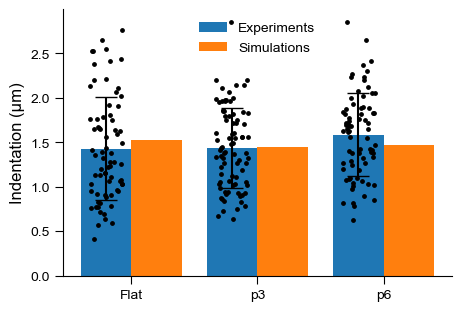

In [161]:
# compare with exp data
plot_idx = 2
curOutput = outputFlattening
simData = [curOutput[0][plot_idx][0], curOutput[1][plot_idx][3], curOutput[1][plot_idx][9]]
load_data = np.loadtxt('new_yaptaz_nanopillar_data.csv', skiprows=1, delimiter=',')
flatData = load_data[load_data[:,0]==0]
p3Data = load_data[load_data[:,0]==3]
p6Data = load_data[load_data[:,0]==6]
expMeans = [np.average(flatData[:,9]), np.average(p3Data[:,9]), np.average(p6Data[:,9])]#[1.4188, 1.4275, 1.5407]
expStd = [np.std(flatData[:,9]), np.std(p3Data[:,9]), np.std(p6Data[:,9])]#[0.5817, 0.4640, 0.4888]
expData = [flatData[:,9], p3Data[:,9], p6Data[:,9]]
np_means = {
    'Experiments': np.array(expMeans),
    'Simulations': np.array(simData),
}
width = 0.4
x = np.array([0,1,2])#[::2]))  # the label locations
multiplier = 0
fig, ax = plt.subplots(layout='constrained', figsize=(4.5,3))
for attribute, measurement in np_means.items():
    offset = width * multiplier
    if attribute == "Experiments":
        rects = ax.bar(x + offset, measurement, width, 
                       yerr=expStd, label=attribute)#, hatch='///')
        for i in range(len(expData)):
            randScatter = x[i] + offset + np.random.uniform(-width/3, width/3, size=len(expData[i])) 
            ax.scatter(randScatter, expData[i], color="black", s=6)
    else:
        rects = ax.bar(x + offset, measurement, width, label=attribute)#, hatch='///')
    # ax.bar_label(rects, padding=3)
    multiplier += 1
ax.set_ylabel('Indentation (µm)')
ax.set_xticks(x + width/2, ['Flat','p3','p6'])#[::2])
ax.legend()#loc='upper right')
plt.savefig("compare_flattening.pdf", format="pdf")

In [ ]:
import numpy as np
from scipy.stats import f_oneway, tukey_hsd
# 1. Define your sample groups (arrays can be different lengths)

group_A = expData[0]
group_B = expData[1]
group_C = expData[2]

# 2. Perform the One-Way ANOVA
anova_stat, anova_p = f_oneway(group_A, group_B, group_C)
print(f"ANOVA result: F-statistic = {anova_stat:.4f}, p-value = {anova_p:.4f}\n")

# 3. Perform Tukey's HSD test if ANOVA p-value is significant (< 0.05)
if anova_p < 0.05:
    res = tukey_hsd(group_A, group_B, group_C)
    print(res)
else:
    print("ANOVA is not statistically significant; post-hoc test not required.")


ValueError: shape mismatch: objects cannot be broadcast to a single shape.  Mismatch is between arg 0 with shape (2,) and arg 1 with shape (3,).

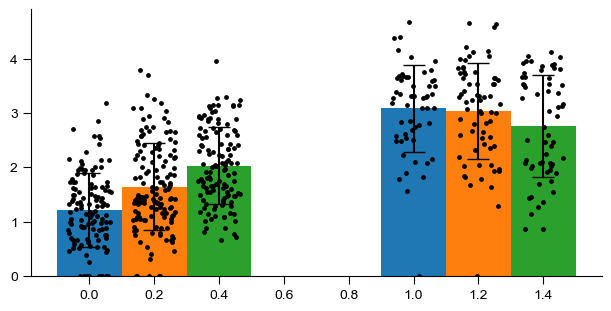

In [173]:
plt.rcParams['axes.prop_cycle'] = plt.cycler(color=plt.colormaps['tab10'].colors)
# compare with exp data
plot_idx = 2
curOutput = outputIndentation
# simData = [curOutput[0][plot_idx][0], 
simData = [curOutput[1][plot_idx][3], curOutput[1][plot_idx][9]]
load_data = np.genfromtxt('3cellindent.csv', delimiter=',')
load_data_2hr = load_data[load_data[:,1]==2]
p3Data_2hr = load_data_2hr[load_data_2hr[:,3]==3]
p6Data_2hr = load_data_2hr[load_data_2hr[:,3]==6]
expData_2hr = [p3Data_2hr[:,7], p6Data_2hr[:,7]]
expMeans_2hr = [np.average(p3Data_2hr[:,7]), np.average(p6Data_2hr[:,7])]#[1.4188, 1.4275, 1.5407]
expStd_2hr = [np.std(p3Data_2hr[:,7]), np.std(p6Data_2hr[:,7])]#[0.5817, 0.4640, 0.4888]

load_data_5hr = load_data[load_data[:,1]==5]
p3Data_5hr = load_data_5hr[load_data_5hr[:,3]==3]
p6Data_5hr = load_data_5hr[load_data_5hr[:,3]==6]
expData_5hr = [p3Data_5hr[:,7], p6Data_5hr[:,7]]
expMeans_5hr = [np.average(p3Data_5hr[:,7]), np.average(p6Data_5hr[:,7])]#[1.4188, 1.4275, 1.5407]
expStd_5hr = [np.std(p3Data_5hr[:,7]), np.std(p6Data_5hr[:,7])]#[0.5817, 0.4640, 0.4888]

load_data_8hr = load_data[load_data[:,1]==8]
p3Data_8hr = load_data_8hr[load_data_8hr[:,3]==3]
p6Data_8hr = load_data_8hr[load_data_8hr[:,3]==6]
expData_8hr = [p3Data_8hr[:,7], p6Data_8hr[:,7]]
expMeans_8hr = [np.average(p3Data_8hr[:,7]), np.average(p6Data_8hr[:,7])]#[1.4188, 1.4275, 1.5407]
expStd_8hr = [np.std(p3Data_8hr[:,7]), np.std(p6Data_8hr[:,7])]#[0.5817, 0.4640, 0.4888]
np_means = {
    'Exp (2 hr)': np.array(expMeans_2hr),
    'Exp (5 hr)': np.array(expMeans_5hr),
    'Exp (8 hr)': np.array(expMeans_8hr),
    'Simulations': np.array(simData),
}
expStds = [expStd_2hr, expStd_5hr, expStd_8hr]
expDatasets = [expData_2hr, expData_5hr, expData_8hr]
width = 0.2
x = np.array([0,1])#[::2]))  # the label locations
multiplier = 0
fig, ax = plt.subplots(layout='constrained', figsize=(6,3))
for attribute, measurement in np_means.items():
    offset = width * multiplier
    if "2 hr" in attribute:
        rects = ax.bar(x + offset, measurement, width, 
                       yerr=expStd_2hr, label=attribute)#, hatch='///')
        for i in range(len(expData_2hr)):
            randScatter = x[i] + offset + np.random.uniform(-width/3, width/3, size=len(expData_2hr[i])) 
            ax.scatter(randScatter, expData_2hr[i], color="black", s=6)
    elif "5 hr" in attribute:
        rects = ax.bar(x + offset, measurement, width, 
                        yerr=expStd_5hr, label=attribute)#, hatch='///')
        for i in range(len(expData_5hr)):
            randScatter = x[i] + offset + np.random.uniform(-width/3, width/3, size=len(expData_5hr[i])) 
            ax.scatter(randScatter, expData_5hr[i], color="black", s=6)
    elif "8 hr" in attribute:
        rects = ax.bar(x + offset, measurement, width, 
                        yerr=expStd_8hr, label=attribute)#, hatch='///')
        for i in range(len(expData_8hr)):
            randScatter = x[i] + offset + np.random.uniform(-width/3, width/3, size=len(expData_8hr[i])) 
            ax.scatter(randScatter, expData_8hr[i], color="black", s=6)
    else:
        rects = ax.bar(x + offset, measurement, width, label=attribute)#, hatch='///')
    # ax.bar_label(rects, padding=3)
    multiplier += 1
ax.set_ylabel('Indentation (µm)')
ax.set_xticks(x+width, ['p3','p6'])#[::2])
plt.ylim([0,5])
plt.xlim([-width/2-0.1,1+5*width/2+0.1])
ax.legend()#loc='upper right')
plt.savefig("indent_timepoints.pdf", format="pdf")

In [ ]:
import numpy as np
from scipy.stats import f_oneway, tukey_hsd, ttest_ind
# 1. Define your sample groups (arrays can be different lengths)

group_A2 = p3Data_2hr[:,7]
group_B2 = p6Data_2hr[:,7]
group_A5 = p3Data_5hr[:,7]
group_B5 = p6Data_5hr[:,7]
group_A8 = p3Data_8hr[:,7]
group_B8 = p6Data_8hr[:,7]
# 2. Perform the One-Way ANOVA
# anova_stat, anova_p = f_oneway(group_A2, group_B2, group_A5, group_B5, group_A8, group_B8)
# print(f"ANOVA result: F-statistic = {anova_stat:.4f}, p-value = {anova_p:.4f}\n")

# 3. Perform Tukey's HSD test if ANOVA p-value is significant (< 0.05)
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols

# 1. Create dummy data (Example: Plant growth based on Fertilizer and Watering)
data = pd.DataFrame({
    'timepoint': np.concatenate((p3Data_2hr[:,1], p3Data_5hr[:,1], p3Data_8hr[:,1],
                                p6Data_2hr[:,1], p6Data_5hr[:,1], p6Data_8hr[:,1])),
    'pitch': np.concatenate((p3Data_2hr[:,3], p3Data_5hr[:,3], p3Data_8hr[:,3],
                            p6Data_2hr[:,3], p6Data_5hr[:,3], p6Data_8hr[:,3])),
    'indentation': np.concatenate((p3Data_2hr[:,7], p3Data_5hr[:,7], p3Data_8hr[:,7],
                                  p6Data_2hr[:,7], p6Data_5hr[:,7], p6Data_8hr[:,7])),
})

# 2. Fit the Ordinary Least Squares (OLS) model 
# Use '*' to include both Main Effects and their Interaction Effect
model = ols('indentation ~ C(timepoint) * C(pitch)', data=data).fit()

# 3. Perform Two-Way ANOVA
anova_table = sm.stats.anova_lm(model, typ=2)

# 4. Display results
print(anova_table)

# Tukey
if anova_p < 0.05:
    res = tukey_hsd(group_A2, group_A5, group_A8, group_B2, group_B5, group_B8)
    print(res)
else:
    print("ANOVA is not statistically significant; post-hoc test not required.")

In [ ]:
plot_idx = 1
np_means = {
    'Radius=200nm': np.array(outputStress[1][plot_idx])/1000,
    # 'Radius=500nm': np.array(outputStress[2][plot_idx])/1000,
}
width = 0.4
x = np.arange(len(outputStress[0][1]))#[::2]))  # the label locations
multiplier = 0
fig, ax = plt.subplots(layout='constrained', figsize=(5,4))
for attribute, measurement in np_means.items():
    offset = width * multiplier
    rects = ax.bar(x + offset, measurement, width, label=attribute)#, hatch='///')
    # ax.bar_label(rects, padding=3)
    multiplier += 1
ax.set_ylabel('NE integrated stress (nN)')
ax.set_xticks(x + width/2, pitchVec)#[::2])
ax.set_xlabel('Pitch (µm)')
plt.plot(x, outputStress[0][plot_idx][0]*np.ones_like(x)/1000, 'k--', label='flat')
ax.legend()#loc='upper right')
plt.ylim([300,400])
# plt.ylim([0, 45])
# plt.savefig("stress800_pitch_bars_h1.5.pdf", format="pdf")

ROOT -2026-09-22 14:10:00,484 fontTools.subset - INFO - maxp pruned (__init__.py:2783)
ROOT -2026-09-22 14:10:00,485 fontTools.subset - INFO - LTSH dropped (__init__.py:2767)
ROOT -2026-09-22 14:10:00,486 fontTools.subset - INFO - cmap pruned (__init__.py:2783)
ROOT -2026-09-22 14:10:00,490 fontTools.subset - INFO - kern pruned (__init__.py:2783)
ROOT -2026-09-22 14:10:00,490 fontTools.subset - INFO - post pruned (__init__.py:2783)
ROOT -2026-09-22 14:10:00,491 fontTools.subset - INFO - PCLT dropped (__init__.py:2767)
ROOT -2026-09-22 14:10:00,492 fontTools.subset - INFO - GSUB pruned (__init__.py:2783)
ROOT -2026-09-22 14:10:00,493 fontTools.subset - INFO - JSTF dropped (__init__.py:2767)
ROOT -2026-09-22 14:10:00,494 fontTools.subset - INFO - DSIG dropped (__init__.py:2767)
ROOT -2026-09-22 14:10:00,495 fontTools.subset - INFO - name pruned (__init__.py:2783)
ROOT -2026-09-22 14:10:00,501 fontTools.subset - INFO - glyf pruned (__init__.py:2783)
ROOT -2026-09-22 14:10:00,503 fontTools

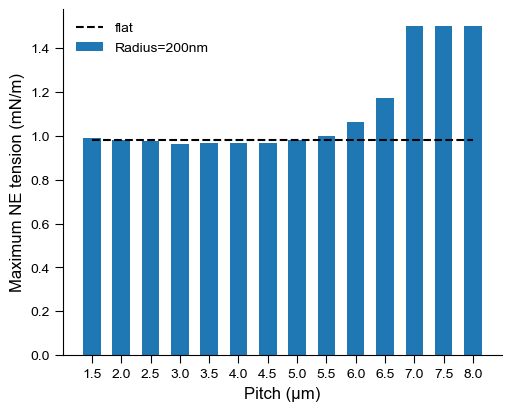

In [162]:
plot_idx = 2
np_means = {
    'Radius=200nm': 0.05*np.array(outputTension[1][plot_idx])/2000,
    # 'Radius=500nm': 0.05*np.array(outputTension[2][plot_idx])/2000,
}
width = 0.6
x = np.arange(len(outputStress[0][1]))#[::2]))  # the label locations
multiplier = 0
fig, ax = plt.subplots(layout='constrained', figsize=(5,4))
for attribute, measurement in np_means.items():
    offset = width * multiplier
    rects = ax.bar(x + offset, measurement, width, label=attribute)#, hatch='///')
    # ax.bar_label(rects, padding=3)
    multiplier += 1
ax.set_ylabel('Maximum NE tension (mN/m)')
ax.set_xticks(x, pitchVec)#[::2])
ax.set_xlabel('Pitch (µm)')
plt.plot(x, 0.05*outputTension[0][plot_idx][0]*np.ones_like(x)/2000, 'k--', label='flat')
ax.legend()#loc='upper right')
# plt.ylim([0,1.5])
# plt.ylim([0, 45])
plt.savefig("tension400_pitch_bars_h2.5.pdf", format="pdf")

Make substrates meshes, both with and without vertical shift.

In [149]:
import sys
import dolfin as d
sys.path.append("/root/shared/gitrepos/smart-mechanotransduction/mesh-files")
import spread_cell_mesh_generation as mesh_gen

substrate_mesh_folder = "/root/shared/gitrepos/smart-mechanotransduction/meshes/substrate_meshes_h2.5"

radiusArray=[0.45]#[0.2]#[0.2, 0.5]
pitchArray=[3.5]#[6.0, 3.0]#[1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0, 6.5, 7.0]
heightArray=[3.25]#[2.5]#[1.5, 3.0]
# cellRadArray=[20.25, 18.52, 16.55, 20.01, 17.45, 22.48]

for i in range(len(radiusArray)):
    for j in range(len(heightArray)):
        for k in range(len(pitchArray)):
            rNP = radiusArray[i] + 0.05
            hNP = heightArray[j]
            pNP = pitchArray[k]
            dmesh, mf2, mf3 = mesh_gen.create_substrate(nanopillars=[rNP, hNP, pNP], hEdge = 0.1, LBox=20, TBox=0.05)
            # d.File(f"{substrate_mesh_folder}/substrate_r{rNP}_p{pNP}_h{hNP}.pvd") << dmesh
            d.ALE.move(dmesh, d.Expression(("0","0",f"-{hNP+0.2}"), degree=1))
            d.File(f"{substrate_mesh_folder}/substrate_r{rNP}_p{pNP}_h{hNP}.pvd") << dmesh

In [ ]:
# assess average volumes and surface areas at start
radVec = [0.0, 0.2, 0.5]#, 0.5]#, 0.2]#, 0.1]
pitchVec = [1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0, 5.5, 6.0, 6.5, 7.0]
for rads in radVec:
    if rads == 0:
        pitchIt = [0]
    else:
        pitchIt = range(len(pitchVec))
    for m in pitchIt:
        if rads==0:
            results_folder = f"/root/scratch/new_nuconly_sims/results_nanopillars_nuconly_2026-01-15_sweep/nucmech_flat"
        else:
            results_folder = f"/root/scratch/new_nuconly_sims/results_nanopillars_nuconly_2026-01-15_sweep/nucmech_nanopillars_h1.5_p{pitchVec[m]}_r{rads}"
        kRamp = np.loadtxt(f"{results_folder}/kRamp.txt")
        pRamp = np.loadtxt(f"{results_folder}/pRamp.txt")
        vol = np.loadtxt(f"{results_folder}/vol.txt")
        vol_inner = np.loadtxt(f"{results_folder}/vol_inner.txt")
        outer_SA = np.loadtxt(f"{results_folder}/outer_SA.txt")
        inner_SA = np.loadtxt(f"{results_folder}/inner_SA.txt")
        plt.plot(kRamp[0:201],inner_SA[0:201])
        print(max(inner_SA))
        # print(max(vol_inner[0:201]+vol[0:201]))
        # plt.ylim([800,1000])

In [ ]:
noBoostPress = np.loadtxt("/root/scratch/nuc_flat_anderson_bothSidesPressure/pRamp.txt") 
noBoostVol = np.loadtxt("/root/scratch/nuc_flat_anderson_bothSidesPressure/vol_inner.txt")
withBoostPress = np.loadtxt("/root/scratch/nuc_flat_anderson_withPressBoost/pRamp.txt")
withBoostVol = np.loadtxt("/root/scratch/nuc_flat_anderson_withPressBoost/vol_inner.txt")
plt.plot(noBoostVol[10:], noBoostPress[10:len(noBoostVol)])
plt.plot(withBoostVol[10:], withBoostPress[10:len(withBoostVol)])